In [ ]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops

In [ ]:
df_manifest = pd.read_csv("../data/manifest_crop.csv")
sample = df_manifest.iloc[0]

In [3]:
img_path = f"../data/preprocessed/{sample['label']}/{sample['filename']}"
img = cv2.imread(img_path)

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [5]:
glcm = graycomatrix(
    gray,
    distances=[1],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=256,
    symmetric=True,
    normed=True
)

In [6]:
contrast    = graycoprops(glcm, 'contrast').mean()
correlation = graycoprops(glcm, 'correlation').mean()
energy      = graycoprops(glcm, 'energy').mean()
homogeneity = graycoprops(glcm, 'homogeneity').mean()

In [7]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h_mean = hsv[:, :, 0].mean()
s_mean = hsv[:, :, 1].mean()
v_mean = hsv[:, :, 2].mean()

In [8]:
print(f"File     : {sample['filename']}")
print(f"Label    : {sample['label']}")
print(f"Contrast : {contrast:.4f}")
print(f"Correlation : {correlation:.4f}")
print(f"Energy   : {energy:.4f}")
print(f"Homogeneity : {homogeneity:.4f}")
print(f"Hue mean : {h_mean:.2f}")
print(f"Saturation mean : {s_mean:.2f}")
print(f"Value mean : {v_mean:.2f}")

File     : normal_001_biji1.jpg
Label    : sehat
Contrast : 45.0331
Correlation : 0.9945
Energy   : 0.0259
Homogeneity : 0.2970
Hue mean : 35.09
Saturation mean : 106.65
Value mean : 144.80


In [9]:
fitur_list = []

for idx, row in df_manifest.iterrows():
    img_path = f"../data/preprocessed/{row['label']}/{row['filename']}"
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )
    contrast    = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy      = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_mean = hsv[:, :, 0].mean()
    s_mean = hsv[:, :, 1].mean()
    v_mean = hsv[:, :, 2].mean()

    fitur_list.append({
        "filename": row['filename'],
        "label": row['label'],
        "contrast": contrast,
        "correlation": correlation,
        "energy": energy,
        "homogeneity": homogeneity,
        "hue": h_mean,
        "saturation": s_mean,
        "value": v_mean
    })

df_fitur = pd.DataFrame(fitur_list)
df_fitur.to_csv("../data/manifest_fitur.csv", index=False)

print(f"Total gambar diproses: {len(df_fitur)}")
df_fitur.head()

Total gambar diproses: 105


,filename,label,contrast,correlation,energy,homogeneity,hue,saturation,value
0,normal_001_biji1.jpg,sehat,45.033056,0.994459,0.025865,0.296995,35.086426,106.652283,144.803711
1,normal_001_biji2.jpg,sehat,86.511081,0.987162,0.021394,0.211405,49.856750,93.116211,128.600281
2,normal_002_biji1.jpg,sehat,32.220664,0.996681,0.029301,0.301938,43.304871,81.158569,143.197998
3,normal_002_biji2.jpg,sehat,27.697569,0.996925,0.025981,0.288653,38.917358,61.488342,136.881470
4,normal_002_biji3.jpg,sehat,24.625332,0.996660,0.027738,0.313351,34.302063,92.151306,139.510864


In [10]:
df_fitur.describe()
df_fitur.isnull().sum()

filename       0
label          0
contrast       0
correlation    0
energy         0
homogeneity    0
hue            0
saturation     0
value          0
dtype: int64

In [11]:
df_fitur.describe()

,contrast,correlation,energy,homogeneity,hue,saturation,value
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,31.004513,0.994442,0.032187,0.316162,45.486143,87.853513,123.843517
std,10.819144,0.009726,0.009660,0.048156,11.649325,17.610590,17.570920
min,3.141048,0.899734,0.021394,0.200817,31.892273,32.358154,56.591736
25%,25.023469,0.994924,0.026901,0.284148,40.158325,77.286560,113.209473
50%,30.199786,0.995629,0.029832,0.306412,43.250061,88.419067,128.600281
75%,36.326098,0.996536,0.034044,0.340123,46.625183,99.766479,135.932800
max,86.511081,0.998483,0.082853,0.478230,104.250488,134.891846,159.766052


In [12]:
print("Correlation terendah:")
print(df_fitur.sort_values("correlation").head(5)[["filename", "label", "contrast", "correlation", "energy", "hue", "value"]])

print("\nEnergy tertinggi:")
print(df_fitur.sort_values("energy", ascending=False).head(5)[["filename", "label", "contrast", "correlation", "energy", "hue", "value"]])

print("\nHue tertinggi:")
print(df_fitur.sort_values("hue", ascending=False).head(5)[["filename", "label", "contrast", "correlation", "energy", "hue", "value"]])

Correlation terendah:
                 filename           label   contrast  correlation    energy  \
71    virus_030_biji1.jpg  terkontaminasi  29.512189     0.899734  0.038737   
36   normal_026_biji2.jpg           sehat   3.141048     0.971509  0.082853   
1    normal_001_biji2.jpg           sehat  86.511081     0.987162  0.021394   
102   virus_053_biji2.jpg  terkontaminasi  70.557478     0.990299  0.033978   
100   virus_052_biji1.jpg  terkontaminasi  52.152890     0.992676  0.030073   

            hue       value  
71   104.250488   87.303284  
36   103.000000   56.591736  
1     49.856750  128.600281  
102   48.407898  120.021423  
100   32.887268  145.638428  

Energy tertinggi:
                 filename           label   contrast  correlation    energy  \
36   normal_026_biji2.jpg           sehat   3.141048     0.971509  0.082853   
40   normal_030_biji1.jpg           sehat  21.573284     0.996593  0.081548   
87    virus_045_biji1.jpg  terkontaminasi  29.447047     0.997300  

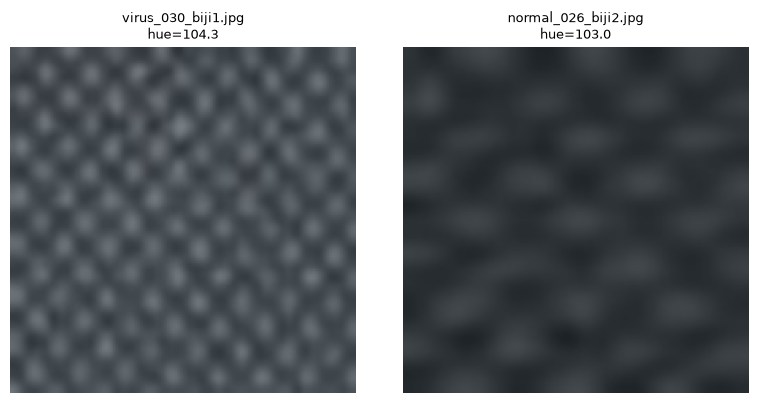

In [13]:
import matplotlib.pyplot as plt

kandidat = ["virus_030_biji1.jpg", "normal_026_biji2.jpg"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, nama_file in enumerate(kandidat):
    row = df_fitur[df_fitur["filename"] == nama_file].iloc[0]
    path_crop = f"../data/cropped/{row['label']}/{nama_file}"
    path_pre = f"../data/preprocessed/{row['label']}/{nama_file}"

    img = cv2.imread(path_pre)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{nama_file}\nhue={row['hue']:.1f}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [14]:
bad_files = ["virus_030_biji1.jpg", "normal_026_biji2.jpg"]
df_fitur_clean = df_fitur[~df_fitur["filename"].isin(bad_files)].reset_index(drop=True)

print(f"Sebelum dibuang: {len(df_fitur)} baris")
print(f"Setelah dibuang: {len(df_fitur_clean)} baris")
print(df_fitur_clean["label"].value_counts())

df_fitur_clean.to_csv("../data/manifest_fitur.csv", index=False)

Sebelum dibuang: 105 baris
Setelah dibuang: 103 baris
label
terkontaminasi    63
sehat             40
Name: count, dtype: int64
